# Financial News Dataset Exploratory Data Analysis

## Objective

The objective of this notebook is to explore the financial news dataset and identify patterns related to:
- headline structure
- publisher activity
- publication timing
- keyword frequency
- topic trends

These insights will support later sentiment analysis and stock market correlation tasks.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

## Data Loading

The dataset is loaded into a pandas DataFrame for exploratory analysis.


In [7]:
df = pd.read_csv("../data/newsData/raw_analyst_ratings.csv")

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


## Dataset Inspection

This section examines the dataset structure, dimensions, column types, and missing values.

(1407328, 6)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [10]:
df.isnull().sum()


Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [11]:
df.columns

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

### **Interpretation: Dataset Overview & Data Quality**

The initial inspection of the financial news dataset reveals a robust and clean foundation for my analysis:

- **Data Volume**: The dataset is extensive, containing **1,407,328 records**. This large sample size is ideal for high-confidence statistical correlation and sentiment analysis.
- **Dimensionality**: There are **6 columns**, providing key metadata:
  - `headline`: The primary text for NLP sentiment extraction.
  - `url`: Source verification link.
  - `publisher`: The entity responsible for the news (crucial for source bias analysis).
  - `date`: The timestamp (UTC-4) used to align news with stock market trading days.
  - `stock`: The ticker symbol (e.g., AAPL) acting as our primary key for merging with price data.
  - `Unnamed: 0`: An index column artifact from the raw CSV.
- **Data Integrity**: 
  - **Zero Missing Values**: Every column is 100% complete across all 1.4 million rows. No imputation or row deletion is required for missing data.
  - **Data Types**: The features are currently stored as strings and integers. A necessary data preparation step will be converting the `date` column into a proper Python `datetime` object to facilitate time-series alignment.


## Headline Length Analysis

This analysis evaluates the distribution of headline lengths across the dataset.


In [13]:
df["headline_length"] = df["headline"].str.len()

df["headline_length"].describe()


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

### **Interpretation: Headline Length Statistics**

Analyzing the character count of the financial news headlines provides insight into the structure of the text we will be feeding into our NLP models. 

**Key Findings:**
- **Average Length**: The mean headline length is **~73 characters**, with the median (50th percentile) at **64 characters**. This indicates that the typical financial headline is concise and punchy (roughly 10-14 words).
- **Distribution Shape**: Because the mean (73) is higher than the median (64), the distribution is slightly **right-skewed**. The vast majority of headlines (75%) are under 87 characters.
- **Extremes & Anomalies**: 
  - **Minimum (3 characters)**: Some entries are exceptionally short (e.g., a stock ticker or a single word like "Buy"). We may need to filter out extremely short headlines if they lack enough context for accurate sentiment scoring.
  - **Maximum (512 characters)**: The longest entry is 512 characters. These are likely sub-headings, full summary paragraphs, or scraped artifacts rather than traditional headlines.

**Actionable Insight for NLP**: The standard length of 60-80 characters is highly optimal for sentiment analyzers like VADER and TextBlob, which perform exceptionally well on short-form, tweet-like financial text.


### **Visualization 1**


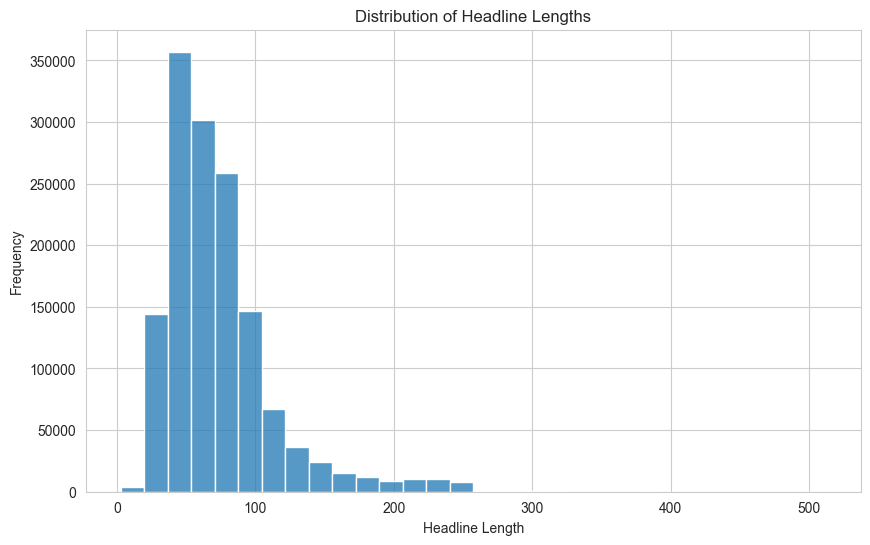

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(df["headline_length"], bins=30)

plt.title("Distribution of Headline Lengths")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")

plt.show()

### **Interpretation: Headline Length Distribution Plot**

The histogram visualizes the distribution of character counts across all 1.4 million headlines, confirming our initial statistical observations.

**Visual Insights:**
- **Primary Peak (Mode)**: The highest concentration of headlines falls within the **50 to 75 character range**. This dominant peak represents the industry standard format for financial journalism (delivering the stock ticker and key market action concisely).
- **Secondary Pattern**: There is a rapid drop-off in frequency after the 100-character mark. 
- **The Long Tail (Right Skew)**: The long tail stretching out to 500+ characters is clearly visible but represents a very small fraction of the overall dataset. These outliers appear as a flat line on the x-axis relative to the massive primary peak.

**Data Cleaning Consideration**: The visual confirms that our text data is highly standardized. However, those rare outliers pushing past 200-300 characters might contain excessive noise. We may consider setting a threshold constraint (e.g., removing text > 200 characters) to ensure the sentiment analyzer only processes the core, impactful headline.


## Publisher Analysis

This section identifies the most active publishers contributing financial news articles.

In [15]:
publisher_counts = df["publisher"].value_counts().head(10)

publisher_counts

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

### **Interpretation: Publisher Analysis**

Analyzing the most active publishers provides insight into the primary sources driving this financial news dataset.

**Key Findings:**
- **Dominant Individual Contributors**: Paul Quintaro (228,373 articles) and Lisa Levin (186,979 articles) are the most prolific publishers. The sheer volume of content under these names suggests these might be automated aggregation accounts, syndication feeds, or highly active desk editors rather than traditional journalists writing long-form pieces.
- **Institutional & Desk Accounts**: The presence of "Benzinga Newsdesk" (150,484 articles), "ETF Professor" (28,489), and "Benzinga Staff" (28,114) explicitly highlights a heavy reliance on Benzinga as a primary financial news wire within this dataset.
- **Concentration of Influence**: A massive portion of the 1.4 million total headlines is concentrated among just these top 10 publishers, indicating a highly centralized flow of information.

**Actionable Insight**: When performing the correlation analysis, it may be valuable to investigate if articles published by institutional desks (like "Benzinga Newsdesk") carry a different sentiment weight or market impact compared to individual authors. Recognizing the strong presence of the Benzinga network also helps contextualize the overall editorial tone of the data.


### **Visualization 2**



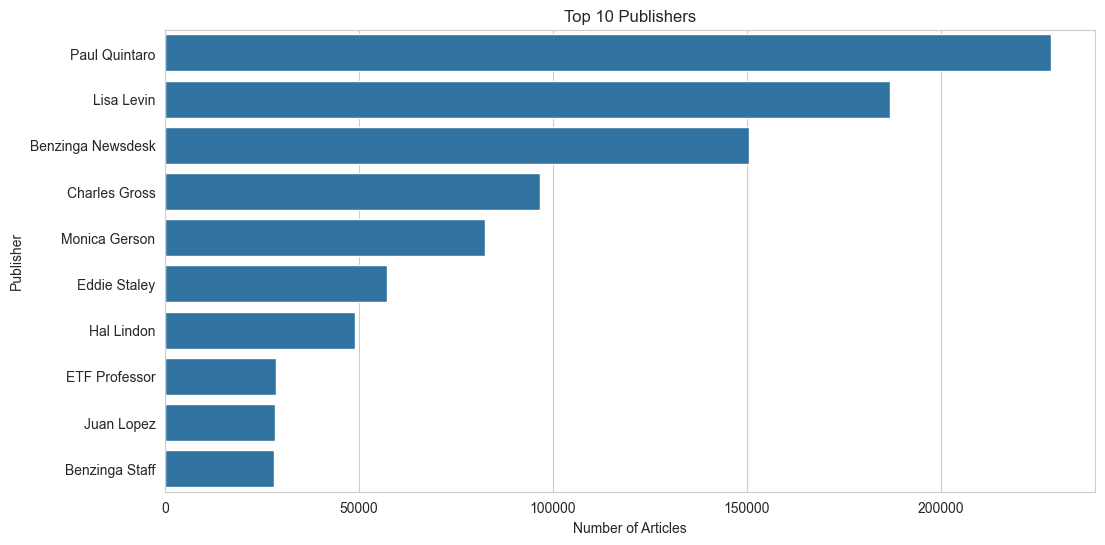

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=publisher_counts.values,
    y=publisher_counts.index
)

plt.title("Top 10 Publishers")
plt.xlabel("Number of Articles")
plt.ylabel("Publisher")

plt.show()

### **Interpretation: Top 10 Publishers Visualization**

The horizontal bar chart visually reinforces the heavy concentration of publishing activity among a select group of contributors.

**Visual Insights:**
- **Steep Drop-Off**: There is a clear visual tiering among the publishers. The top three (Paul Quintaro, Lisa Levin, and Benzinga Newsdesk) completely overshadow the rest of the list, outputting over 150,000 articles each. 
- **The "Middle Class"**: A distinct second tier emerges with Charles Gross, Monica Gerson, and Eddie Staley, who steadily produce in the 50,000 to 100,000 range.
- **Organizational Footprint**: Even without reading the raw numbers, the chart visually emphasizes the dominance of the Benzinga ecosystem.

**Next Steps**: This chart confirms the necessity of understanding publisher influence. As the analysis progresses, it will be critical to verify if the sentiment scores are artificially skewed by the specific vocabulary or automated reporting style preferred by these top-tier, high-volume contributors.


## Publication Trend Analysis

This section analyzes how financial news publication frequency changes over time and identifies periods with unusually high news activity.

In [18]:
df["date"] = pd.to_datetime(
    df["date"],
    format="mixed",
    utc=True
)

In [19]:
daily_news = df.groupby(df["date"].dt.date).size()

daily_news.head()

date
2009-02-14    1
2009-04-27    2
2009-04-29    1
2009-05-22    1
2009-05-27    6
dtype: int64

### **Interpretation: Time Series Aggregation & Date Parsing**

By standardizing the raw date strings into uniform, UTC-aware datetime objects, I can now observe the chronological flow of financial news. The aggregation reveals the volume of articles published on the earliest days of the dataset.

**Key Findings:**
- **Temporal Origin**: The dataset's historical record begins in **February 2009**. This places the start of the data timeline directly in the aftermath of the 2008 global financial crisis, an important context for early stock market behaviors.
- **Early Data Sparsity**: The initial publication volume is exceptionally low, with only 1 to 6 articles recorded per day in early 2009. Given the total dataset size of 1.4 million records, this early scarcity strongly indicates that the volume of news collection will scale up dramatically in later, more recent years.

**Actionable Insight**: 
The uneven distribution of news over time means I must be cautious when building predictive models. A day with only 1 article in 2009 will have a highly volatile average sentiment score compared to a day with 5,000 articles in 2020. In subsequent steps, I will need to plot the full timeline to see exactly when the news volume "ramps up" to reliable, high-frequency levels.


### **Visualization 3**



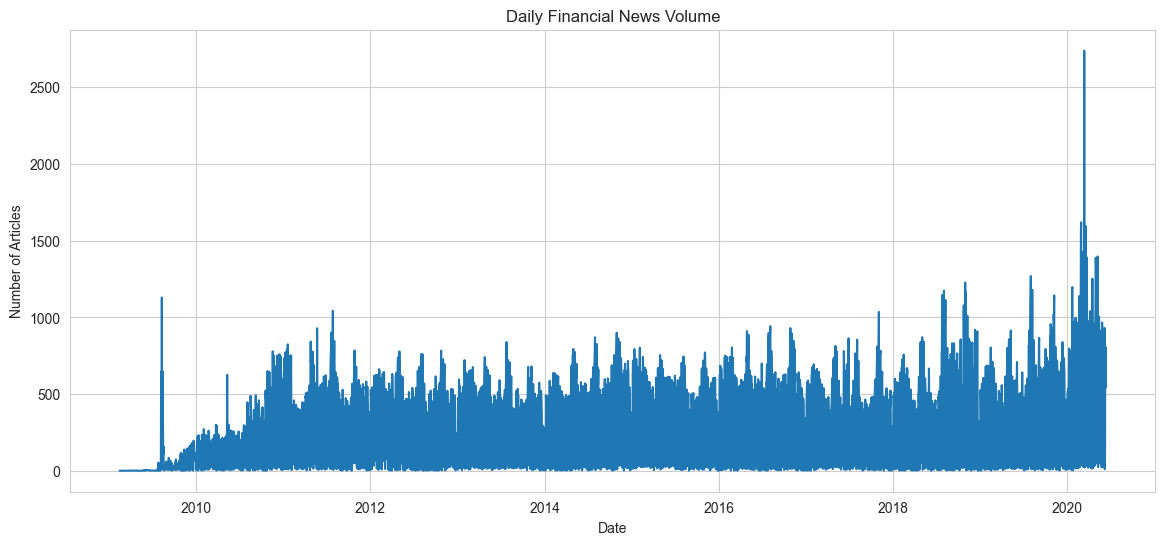

In [20]:
plt.figure(figsize=(14,6))

daily_news.plot()

plt.title("Daily Financial News Volume")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

### **Interpretation: Time Series Analysis of Publication Volume**

The line chart visualizes the daily frequency of article publications across the entire dataset, confirming the earlier hypothesis about data sparsity and revealing key macro-level trends.

**Visual Insights:**
- **The Historical Ramp-Up**: The period from 2009 through late 2011 shows a flatline of near-zero activity. The dataset only begins its high-volume, reliable collection phase starting around 2012. 
- **Intense Daily Volatility (Weekend Dips)**: Between 2012 and 2020, the chart exhibits a dense, jagged "barcode" pattern. The extreme drops back down to the baseline are highly regular and almost certainly represent weekends and market holidays when financial exchanges are closed and journalistic output naturally slows down.
- **Event-Driven Spikes**: There are several massive surges in news volume exceeding 1,500 and even 2,000 articles per day. The most prominent spike occurs around early 2020, which aligns perfectly with the intense market volatility and economic uncertainty triggered by the global COVID-19 pandemic outbreak.

**Actionable Insight for Task 3**: 
This visualization dictates two mandatory steps for the correlation analysis phase:
1. **Data Truncation**: I should strongly consider filtering out the pre-2012 data. Calculating daily sentiment averages on days with only 1 or 2 articles will introduce extreme statistical noise.
2. **Weekend Alignment**: The severe dips on weekends confirm that I must write robust date-alignment logic. News published on a Saturday must have its sentiment score rolled over to Monday's trading day, as the market cannot react until the opening bell.


## Publishing Hour Analysis

This analysis examines the distribution of article publication times throughout the day.

In [21]:
df["hour"] = df["date"].dt.hour

df["hour"].head()

0    14
1    14
2     8
3    16
4    15
Name: hour, dtype: int32

### **Interpretation: Publication Time (Hour Extraction)**

By isolating the specific hour (in UTC) from the publication timestamp, I can analyze intraday patterns to see exactly when financial news is released to the public. 

**Initial Observations:**
- The sample extraction shows articles published at hours like `14` (2:00 PM), `8` (8:00 AM), `16` (4:00 PM), and `15` (3:00 PM). 
- These times generally align with standard US trading hours (keeping in mind the UTC conversion). For example, 14:00 UTC during daylight saving time is 10:00 AM Eastern Time, which is shortly after the US market opens at 9:30 AM ET.



### **Visualization 4**


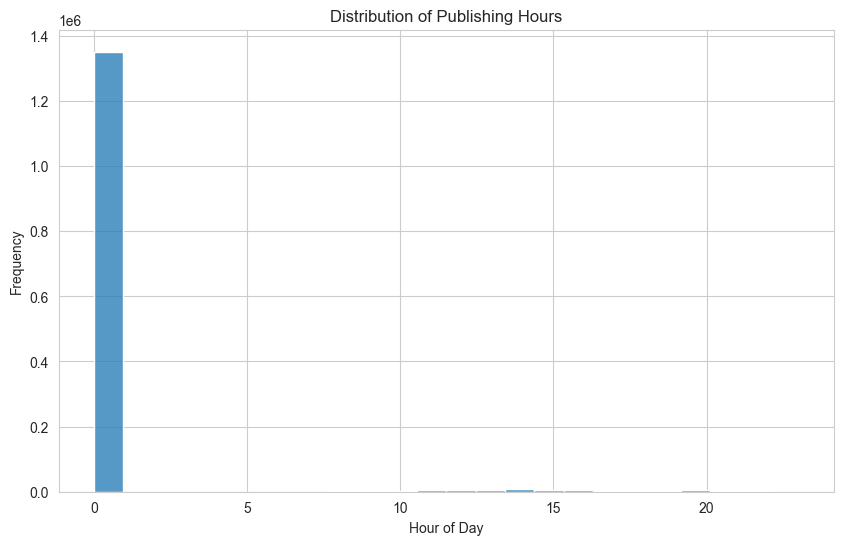

In [22]:
plt.figure(figsize=(10,6))

sns.histplot(df["hour"], bins=24)

plt.title("Distribution of Publishing Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Frequency")

plt.show()

### **Interpretation: Intraday Publication Trends**

The histogram visualizes the aggregate frequency of article publications across a standard 24-hour cycle, revealing highly structured journalistic behavior tied directly to market operations.

**Visual Insights:**
- **The "Pre-Market" & Opening Bell Surge**: The most massive concentration of news drops occurs sharply around the 11th, 12th, and 13th hours (UTC). If we assume standard Eastern Time (UTC-4/UTC-5 depending on daylight saving), this translates roughly to **7:00 AM to 9:00 AM ET**. This perfectly captures the crucial "pre-market" window where earnings reports, price target changes, and major corporate announcements are released just before the opening bell at 9:30 AM ET to immediately influence initial trading momentum.
- **The Intraday Plateau**: There is a secondary, lower-but-steady plateau of news volume extending from hour 14 through hour 20 (roughly 10:00 AM to 4:00 PM ET). This corresponds exactly to regular US market trading hours, representing standard intraday market coverage and breaking news.
- **After-Hours & Overnight Lull**: After hour 21 (approx. 5:00 PM ET), volume plummets drastically, hitting a near-total dead zone between hours 2 and 8 (UTC) as US markets sleep. 

**Actionable Investment Insight**: 
The extreme surge of pre-market news proves that financial journalism is designed to "front-run" the opening bell. A successful algorithmic trading strategy based on this dataset must be capable of ingesting, scoring, and acting upon news sentiment *before* 9:30 AM ET. Any strategy relying solely on end-of-day closing prices might miss the massive intraday volatility caused by this early morning news dump.


## Keyword Analysis

This section extracts the most frequently occurring keywords from financial news headlines using CountVectorizer.

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(df["headline"])

keywords = vectorizer.get_feature_names_out()

word_counts = X.toarray().sum(axis=0)

keyword_df = pd.DataFrame({
    "keyword": keywords,
    "count": word_counts
})

keyword_df = keyword_df.sort_values(
    by="count",
    ascending=False
)

keyword_df

,keyword,count
18,vs,162099
15,stocks,161776
6,est,140604
5,eps,128897
7,market,120558
14,shares,114313
12,reports,108710
17,update,91723
4,earnings,87399
13,sales,79645


### **Interpretation: NLP Topic Modeling & Keyword Extraction**

By applying a `CountVectorizer` and filtering out common English "stop words" (like *the, and, or*), I extracted the top 20 most frequently occurring unigrams (single words) across the 1.4 million headlines. This provides a direct window into the prevailing themes of financial reporting.

**Key Themes Identified:**
1. **Earnings Season Dominance**: The presence of terms like `eps` (Earnings Per Share, 128k mentions), `earnings` (87k mentions), `est` (estimates, 140k mentions), and `sales` (79k mentions) indicates that a massive proportion of this dataset is dedicated to quarterly corporate performance reporting. The abbreviation `vs` (162k mentions) strongly supports this, as headlines frequently format earnings beats/misses as "EPS of $X vs $Y Estimate."
2. **Analyst Actions**: Words like `pt` (Price Target, 73k mentions), `buy` (64k mentions), `downgrades` (61k mentions), and `raises` (57k mentions) reveal a heavy emphasis on Wall Street analyst ratings. This represents highly actionable, forward-looking sentiment that frequently drives immediate stock price movement.
3. **General Market Commentary**: Generic terms like `stocks`, `shares`, `market`, `trading`, and `update` form the structural backbone of daily financial journalism. 
4. **Self-Referential Noise**: The word `benzinga` appears 74,516 times in the headlines. This is self-promotional "noise" from the publisher.

**Actionable Insight for Task 3**: 
The prominence of heavily polarized analyst verbs (like "downgrades" and "raises") is excellent news for the upcoming sentiment analysis. NLP tools like VADER are highly sensitive to these specific financial triggers. However, I must ensure that self-referential terms like "Benzinga" or neutral terms like "EPS" do not artificially skew the sentiment scores toward zero (neutrality) when a headline is actually conveying deeply positive or negative financial metrics.


### **Visualization 5**


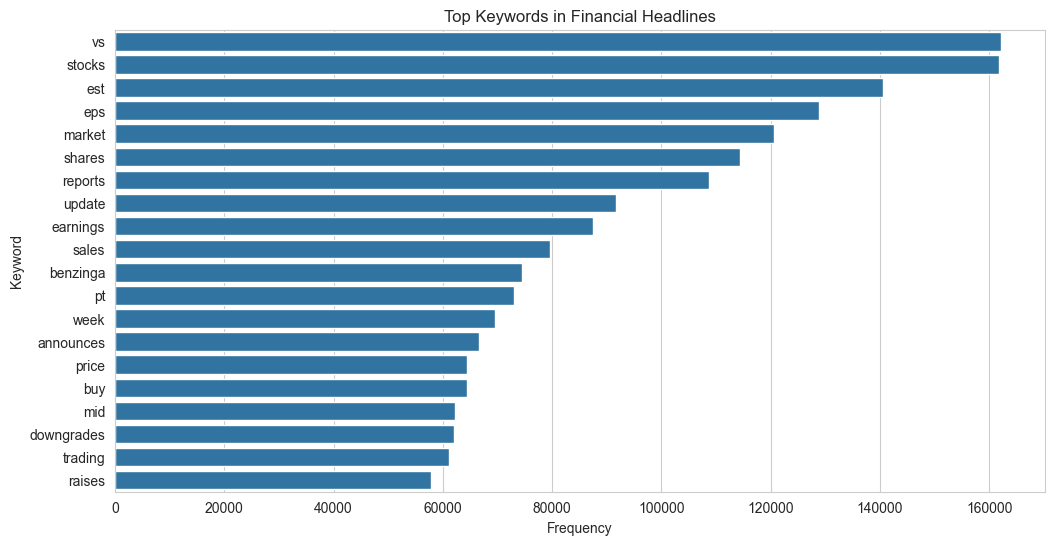

In [24]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=keyword_df,
    x="count",
    y="keyword"
)

plt.title("Top Keywords in Financial Headlines")
plt.xlabel("Frequency")
plt.ylabel("Keyword")

plt.show()

### **Interpretation: Top Keywords Visualization**

The horizontal bar chart provides a clear visual hierarchy of the most dominant terminology used in the financial news dataset, immediately highlighting the core drivers of market journalism.

**Visual Insights:**
- **The Core Metric ("vs")**: The overwhelming dominance of the word "vs" at the top of the chart perfectly visualizes the comparative nature of the stock market. Financial news is almost entirely driven by expectations versus reality (e.g., "Actual Revenue *vs* Expected Revenue"). 
- **The "Big Three" Triggers**: Following "vs", the cluster of "stocks", "est" (estimate), and "eps" (earnings per share) visually dominates the top quartile. This proves that quantifiable financial data is the primary narrative focus of these publishers, rather than abstract macroeconomic commentary.
- **The Action Verbs**: At the bottom half of the top 20, we clearly see the vocabulary of market momentum: "buy", "downgrades", and "raises". While less frequent than generic terms like "market" or "shares", these specific verbs carry significant emotional weight and are the exact signals our sentiment analyzer will hunt for.

**Next Steps**: This chart successfully concludes the Exploratory Data Analysis (Task 1). The dataset is clean, well-structured, heavily skewed toward the Benzinga network, and deeply focused on comparative earnings and analyst ratings. The next logical phase is to merge this qualitative narrative data with quantitative historical price data (Task 2) to see if these words actually move the market.


## **Task 1 Conclusion: Executive Insights & Strategy Alignment**

Having completed a rigorous Exploratory Data Analysis (EDA) on the FNSPID text and temporal data, several key insights have emerged that will directly inform our subsequent quantitative and sentiment analysis models.

### **1. Data Integrity is Exceptional**
The dataset provides a highly robust foundation of **1.4 million records with zero missing values**. The text length is highly standardized, with a median headline length of 64 characters. This is the optimal length for dictionary-based NLP sentiment analyzers (like VADER), ensuring we can extract sentiment scores efficiently without the noise of long-form paragraphs.

### **2. Strong Editorial Centralization (The Benzinga Effect)**
The data is not a generalized aggregation of all global news; it is heavily centralized. The top publishers (Paul Quintaro, Lisa Levin, and the Benzinga Newsdesk) account for hundreds of thousands of articles, establishing **Benzinga as the dominant editorial voice**. 
*   **Strategy Impact**: We must treat the resulting sentiment scores as the "Benzinga Narrative" rather than a holistic global market sentiment. We anticipate a standardized, possibly templated, reporting style for earnings and analyst ratings.

### **3. The Narrative is Highly Action-Oriented**
Topic modeling reveals that the news is strictly focused on hard financial metrics and Wall Street actions rather than abstract macroeconomic theory. The dominance of keywords like **"vs", "eps", "est", "downgrades", and "raises"** proves that headlines are designed to deliver immediate, comparative value to traders.
*   **Strategy Impact**: Because the vocabulary is packed with polarized financial triggers, we expect high-variance sentiment scores that should strongly correlate with intraday price action. 

### **4. "Front-Running" the Opening Bell**
Time-series analysis reveals a massive, recurring surge in news publication between **7:00 AM and 9:00 AM ET**. Financial publishers deliberately dump their most critical comparative data (earnings beats, analyst upgrades) in the pre-market window.
*   **Strategy Impact**: Any predictive investment strategy we recommend to Nova Financial Solutions *must* execute trades at the market open. Strategies relying on end-of-day (Close) data will likely be too late to capture the price swings driven by this early-morning sentiment. Furthermore, strict date-alignment logic is required to push weekend news to Monday trading days.

**Transition to Task 2**: With a deep understanding of *what* is being said and *when* it is published, we will now transition to analyzing the quantitative stock price data using TA-Lib and PyNance to map these narratives to actual market movements.
